# 7.19 回答能寫多長，和前文能放多少，有何不同？


你先告訴助手「店名是小小書店」，它回「好」。下一輪問「現在只答店名」，希望它寫出「小小書店」就結束。這次回答很短，助手卻仍要讀到前面的店名、誰說了哪句話，以及現在輪到它回答。只數最後這個問題，會漏掉真正送進模型的前文。

我們把對話排成一串，用一個只有16格的紙上例子看清楚。這裡特別指定一份玩具字表：〈user〉是使用者標記，〈assistant〉是助手標記，〈eos〉是這一段結束；每個標記各算一個token。文字片段「店名是小小書店。」「好。」「現在」「只答」「店名。」「小小」「書店」也各自指定為一個token。這是為了容易數格而訂的規則，沒有說一般模型把一句話算一個token，也沒有說每個中文字都算一個token。

照這份字表，已提供的歷史和目前問題排成下面的序列。表中每個由斜線分開的項目佔一格，斜線只用來顯示分隔，不送入模型。

| 這段訊息 | 依序放入的token | 格數 |
| --- | --- | ---: |
| 先前使用者說店名 | 〈user〉／店名是小小書店。／〈eos〉 | 3 |
| 先前助手確認 | 〈assistant〉／好。／〈eos〉 | 3 |
| 現在的要求 | 〈user〉／現在／只答／店名。／〈eos〉 | 5 |
| 輪到助手回答 | 〈assistant〉 | 1 |

全部輸入佔12格。最後的助手標記已經在輸入裡，下一步才開始生成答案；歷史裡的結束標記也佔格，但不會讓新的回答立即停止。把對話依角色與文字排成這種輸入序列，叫作序列化。實際使用別的模型時，要用它配套的對話格式和切詞工具數完這份序列，不能直接沿用這裡的12。

圖中的U、A、E分別代表三種標記，a到g代表上面指定的文字片段。先看第1到12格：它們都是已送入的前文。第13到16格才是預留給新回答的空間。下方填入的f、g、E是手寫的示意回答。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

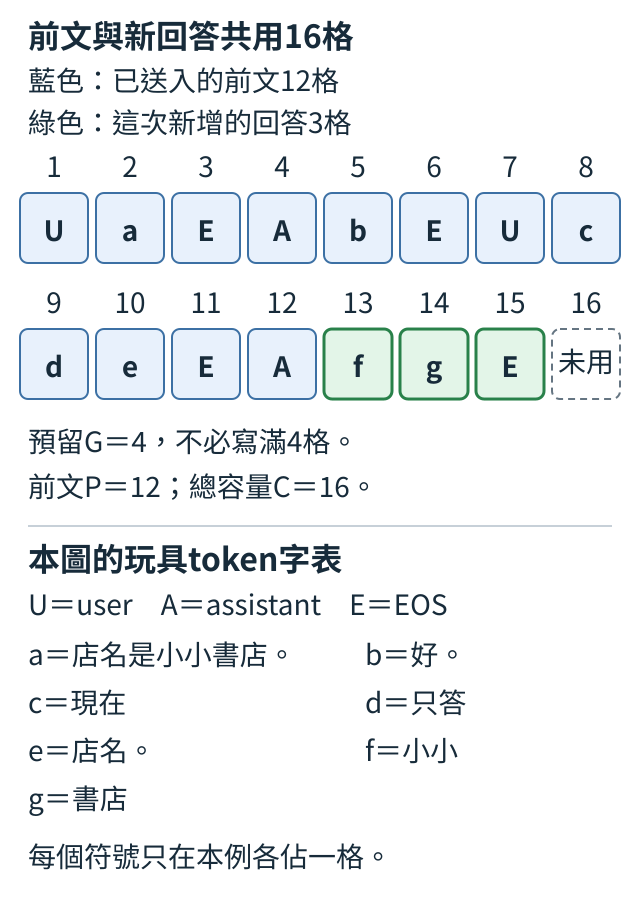

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/new-7.19-sequence-budget.svg")))

這份生成器保留完整歷史，並規定「輸入加上新增結果」最多16格，把這個上限叫C。另有一個設定G，只限制這次最多新增幾個token，常見名稱是max_new_tokens。G不包含已送入的12格，也不會把C改大。本例可以預留G＝4；若把G改成5，原本16格的容量仍不夠。程序需要先處理這個不相容的設定，而不是假裝多出的空間已經存在。

預留4格不代表必須寫滿4格。若接下來是「小小／書店／〈eos〉」，只新增3個token，最後一格沒有使用。EOS也算在新增數量裡：它雖然不顯示成回答文字，仍是模型選出的一個token。沒有使用的容量不是補進輸入的PAD，只是空間還沒用完。

現在只把G改成2。同樣的候選序列最多留下「小小／書店」，讀者已能看見完整店名，卻還沒有生成〈eos〉；這次是預算用完而截停。反過來，若第一步就選〈eos〉，雖然提早停止，店名仍沒回答。回答長度、停止原因和內容完成與否，各自告訴我們不同的事。

練習保持全部前文不變，改成手寫序列「小小／〈eos〉」。它用了幾個新token？是否超過G＝4？有沒有完成「只答店名」？應分別得到2、沒有超過、沒有完成：空間足夠、主動結束，都不能替少掉的「書店」補上證據。

<details>
<summary>補充：長度設定的來源與這個算例的範圍</summary>

Hugging Face Transformers v4.57.1的[GenerationConfig文件](https://github.com/huggingface/transformers/blob/v4.57.1/src/transformers/generation/configuration_utils.py)將max_new_tokens定義為不含prompt的新生成上限；vLLM v0.8.5的[ModelConfig文件](https://github.com/vllm-project/vllm/blob/v0.8.5/vllm/config.py)將max_model_len定義為prompt和output的總長度。本節採保留完整歷史、共用一個總上限的有限例子；滑動窗口或其他模型介面要另看其長度契約。

實際核對正常結束時，還要保存原始token與停止原因，分清模型選EOS、程式強制EOS和其他外部停止條件；不能只看畫面末尾。回答目標與EOS的監督位置沿用[7.3](https://birdhackor.github.io/tiny-perceptron-vlm/7.3.html)、[7.4](https://birdhackor.github.io/tiny-perceptron-vlm/7.4.html)、[7.9](https://birdhackor.github.io/tiny-perceptron-vlm/7.9.html)的安排。來源定位另見[context來源筆記](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-revision-20261005/sources/context.md)。

</details>
